<>:212: SyntaxWarning: invalid escape sequence '\o'
<>:212: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3491/2931392909.py:212: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('r / R$_\odot$')


Integrando n = 3.0...
Integrando n = 3.15...
Integrando n = 3.3...
Integrando n = 3.45...
Integrando n = 3.6...
Advertencia: No se detectó cambio de signo. Usando último punto.
Integrando n = 3.75...
Advertencia: No se detectó cambio de signo. Usando último punto.

=== TABLA DE PARÁMETROS ===
         n       xi1                dtheta1  rho_c/rho_m  -xi1^2 dtheta  omega_n      N_n      W_n  Pc (10^17 dyn/cm²)
0 3.000000  6.896849    -0.0424297576045481    54.182481       2.018236 2.018236 0.363939 0.081035            0.009134
1 3.150000  7.531873    -0.0348326343534082    72.076788       1.976025 1.716378 0.372199 0.074873            0.008439
2 3.300000  8.285036  -0.028222539399060286    97.853661       1.937247 1.470305 0.382779 0.069453            0.007828
3 3.450000  9.191474  -0.022509914915498995   136.110009       1.901710 1.265307 0.395984 0.064672            0.007289
4 3.600000 10.000100  -0.018692271899772007   178.328599       1.869265 1.098754 0.410241 0.060447            0

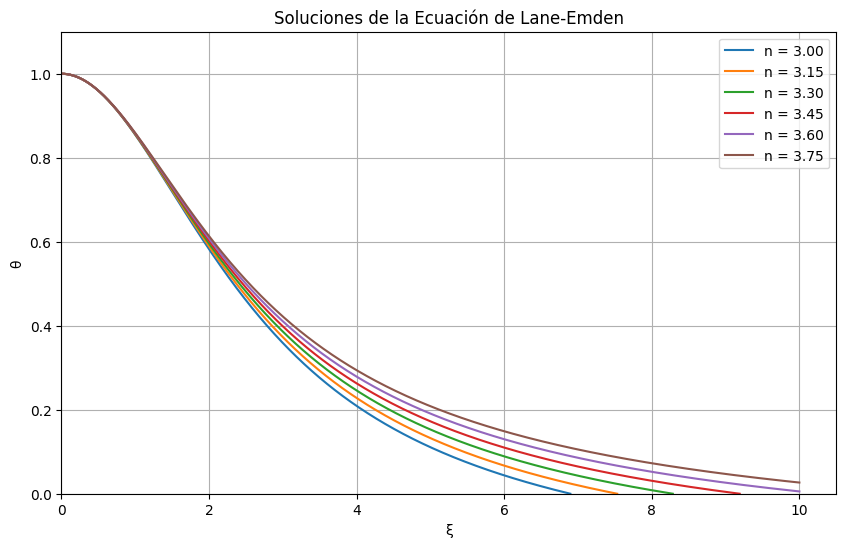

Archivo solar_model.txt no encontrado. Saltando comparación solar.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
import pandas as pd

# Constantes físicas (CGS)
G = 6.674e-8          # cm³ g⁻¹ s⁻²
M_sun = 1.989e33      # g
R_sun = 6.957e10      # cm

# Funciones del sistema de EDOs
def lane_emden_system(xi, y1, y2, n):
    """Retorna [dy1/dxi, dy2/dxi] con manejo seguro de y1**n"""
    if xi == 0:
        return np.array([0.0, 0.0])
    dy1 = y2
    # Evaluar theta**n solo si theta >= 0; si no, fuente nula
    theta_pow = y1**n if y1 >= 0 else 0.0
    dy2 = -theta_pow - (2.0/xi)*y2
    return np.array([dy1, dy2])

def rk4_step(xi, y1, y2, h, n):
    """Un paso de RK4 usando lane_emden_system"""
    k1 = h * lane_emden_system(xi, y1, y2, n)
    k2 = h * lane_emden_system(xi + h/2, y1 + k1[0]/2, y2 + k1[1]/2, n)
    k3 = h * lane_emden_system(xi + h/2, y1 + k2[0]/2, y2 + k2[1]/2, n)
    k4 = h * lane_emden_system(xi + h, y1 + k3[0], y2 + k3[1], n)
    
    y1_new = y1 + (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])/6.0
    y2_new = y2 + (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])/6.0
    return y1_new, y2_new

def taylor_start(h, n):
    """Valores iniciales en xi = h usando expansión de Taylor"""
    theta = 1.0 - h**2/6.0 + n*h**4/120.0
    dtheta = -h/3.0 + n*h**3/30.0
    return theta, dtheta

def find_surface(xi_array, theta_array, dtheta_array):
    """
    Encuentra xi1 y dtheta(xi1) mediante interpolación cúbica
    en la vecindad del cruce por cero.
    """
    # Encontrar índice donde theta cambia de signo (de + a -)
    sign_changes = np.where(np.diff(np.sign(theta_array)))[0]
    if len(sign_changes) == 0:
        # No se encontró cruce: devolver el último valor como aproximación
        print("Advertencia: No se detectó cambio de signo. Usando último punto.")
        xi1 = xi_array[-1]
        # Interpolar dtheta en el último punto
        cs_dtheta = CubicSpline(xi_array[-4:], dtheta_array[-4:])
        dtheta1 = cs_dtheta(xi1)
        return xi1, dtheta1
    
    idx = sign_changes[0]
    # Seleccionar puntos alrededor del cruce para la interpolación
    i1 = max(0, idx-2)
    i2 = min(len(xi_array), idx+3)
    xi_seg = xi_array[i1:i2]
    theta_seg = theta_array[i1:i2]
    dtheta_seg = dtheta_array[i1:i2]
    
    # Interpolador cúbico para theta
    cs_theta = CubicSpline(xi_seg, theta_seg)
    # Encontrar raíz en el intervalo donde ocurre el cambio de signo
    xi_left = xi_array[idx]
    xi_right = xi_array[idx+1]
    try:
        xi1 = brentq(cs_theta, xi_left, xi_right)
    except ValueError:
        # Si falla, usar interpolación lineal
        theta_left = theta_array[idx]
        theta_right = theta_array[idx+1]
        xi1 = xi_left - theta_left * (xi_right - xi_left)/(theta_right - theta_left)
    
    # Interpolar dtheta en xi1
    cs_dtheta = CubicSpline(xi_seg, dtheta_seg)
    dtheta1 = cs_dtheta(xi1)
    
    return xi1, dtheta1

def integrate_lane_emden(n, h=1e-4, max_steps=100000):
    """
    Integra la ecuación de Lane-Emden para índice n.
    Retorna arrays de xi, theta, dtheta y los valores en superficie.
    """
    # Arranque con Taylor
    xi = h
    y1, y2 = taylor_start(h, n)
    
    xi_list = [xi]
    theta_list = [y1]
    dtheta_list = [y2]
    
    for step in range(max_steps):
        y1_new, y2_new = rk4_step(xi, y1, y2, h, n)
        xi_new = xi + h
        
        xi_list.append(xi_new)
        theta_list.append(y1_new)
        dtheta_list.append(y2_new)
        
        if y1_new < 0:
            break
        
        y1, y2, xi = y1_new, y2_new, xi_new
    
    xi_arr = np.array(xi_list)
    theta_arr = np.array(theta_list)
    dtheta_arr = np.array(dtheta_list)
    
    xi1, dtheta1 = find_surface(xi_arr, theta_arr, dtheta_arr)
    return xi_arr, theta_arr, dtheta_arr, xi1, dtheta1

def compute_parameters(n, xi1, dtheta1):
    """Calcula los parámetros físicos solicitados"""
    rho_m = M_sun / (4/3 * np.pi * R_sun**3)
    rho_c = - (xi1/3) / dtheta1 * rho_m
    conc_ratio = rho_c / rho_m
    
    mass_param = -xi1**2 * dtheta1
    
    # Para n != 1, evitamos complejos con valor absoluto
    if n != 1:
        omega = abs(-xi1**((n+1)/(n-1)) * dtheta1)
        Nn = (1/(n+1)) * (4*np.pi / omega**(n-1))**(1/n)
    else:
        omega = 0.0
        Nn = 0.0
    
    Wn = 1/(4*np.pi*(n+1)) * mass_param**2
    Pc = Wn * (G * M_sun**2 / R_sun**4)
    
    return {
        'n': n,
        'xi1': xi1,
        'dtheta1': dtheta1,
        'rho_c/rho_m': conc_ratio,
        '-xi1^2 dtheta': mass_param,
        'omega_n': omega,
        'N_n': Nn,
        'W_n': Wn,
        'Pc (10^17 dyn/cm²)': Pc / 1e17
    }

# Ejecución para todos los n

n_values = [3.00, 3.15, 3.30, 3.45, 3.60, 3.75]
results = []
all_profiles = {}

for n in n_values:
    print(f"Integrando n = {n}...")
    xi_arr, theta_arr, dtheta_arr, xi1, dtheta1 = integrate_lane_emden(n)
    all_profiles[n] = (xi_arr, theta_arr)
    params = compute_parameters(n, xi1, dtheta1)
    results.append(params)

# Tabla de resultados
df = pd.DataFrame(results)
print("\n=== TABLA DE PARÁMETROS ===")
print(df.to_string(float_format="{:.6f}".format))

# Gráfico 1: θ(ξ) para todos los n

plt.figure(figsize=(10,6))
for n in n_values:
    xi_arr, theta_arr = all_profiles[n]
    plt.plot(xi_arr, theta_arr, label=f'n = {n:.2f}')
plt.xlabel('ξ')
plt.ylabel('θ')
plt.title('Soluciones de la Ecuación de Lane-Emden')
plt.legend()
plt.grid(True)
plt.xlim(0, max([all_profiles[n][0][-1] for n in n_values])*1.05)
plt.ylim(0, 1.1)
plt.show()

# Comparación con modelo solar (asumiendo solar_model.txt)

try:
    solar_data = np.loadtxt('solar_model.txt')
    # Asumimos columnas: r/R_sun, rho (g/cm³)
    r_solar = solar_data[:,0]
    rho_solar = solar_data[:,1]
    
    # Para n=3.0
    n_eddington = 3.0
    xi_arr, theta_arr = all_profiles[n_eddington]
    params_n3 = next(p for p in results if p['n']==3.0)
    xi1 = params_n3['xi1']
    r_ratio = xi_arr / xi1
    rho_c = params_n3['rho_c/rho_m'] * (M_sun / (4/3*np.pi*R_sun**3))
    rho_poly = rho_c * theta_arr**n_eddington
    
    # Interpolar en puntos del modelo solar
    from scipy.interpolate import interp1d
    interp_rho = interp1d(r_ratio, rho_poly, kind='cubic', fill_value='extrapolate')
    rho_poly_at_solar = interp_rho(r_solar)
    
    plt.figure(figsize=(10,6))
    plt.plot(r_solar, rho_solar, 'k-', label='Modelo Solar Estándar')
    plt.plot(r_solar, rho_poly_at_solar, 'r--', label='Polítropa n=3 (Eddington)')
    plt.xlabel('r / R$_\odot$')
    plt.ylabel('Densidad (g/cm³)')
    plt.title('Comparación de Perfiles de Densidad')
    plt.legend()
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
except FileNotFoundError:
    print("Archivo solar_model.txt no encontrado. Saltando comparación solar.")
except Exception as e:
    print(f"Error al procesar el modelo solar: {e}")